In [1]:
import matplotlib.pyplot as plt
import scipy.stats as sts
import numpy as np
import cmdstanpy ## import stan interface for Python
import os
import seaborn as sns
import pandas as pd
from importlib import reload 
import sys
sys.path.append("..")
import matplotlib.gridspec as gridspec
import arviz
import matplotlib.image as mpimg
from itertools import product
import matplotlib as mpl
import warnings
warnings.filterwarnings("ignore")
from statannotations.Annotator import Annotator
import matplotlib.patches as mpatches
from matplotlib.ticker import FormatStrFormatter, FuncFormatter

import matplotlib.ticker as mticker
from scipy.optimize import curve_fit
from scipy.special import logit, expit
def downfunc(x,a,b):
    return (a*np.exp(-b*(x)))

def naivedownfunc(x,a,b):
    return (a*(1-np.exp(-b*(x-5))))
# label_size = 30
# mpl.rcParams['xtick.labelsize'] = label_size 
# mpl.rcParams['ytick.labelsize'] = label_size 


tex_fonts = {
    # Use LaTeX to write all text
#     "text.usetex": True,
    "font.family": "Helvetica",
    # Use 10pt font in plots, to match 10pt font in document
    "axes.labelsize": 7,
    "font.size": 7,
    # Make the legend/label fonts a little smaller
    "legend.fontsize": 6,
    "xtick.labelsize": 6,
    "ytick.labelsize": 6,
    "axes.grid": True,
    'grid.color': '#DDDDDD',
    'grid.linestyle': '-',
    'grid.linewidth': 0.3,
    "lines.markersize":4,
    
    'axes.axisbelow':True,
    'lines.linewidth':1,
    'pdf.fonttype':42,
    'axes.linewidth':0.6,
    'xtick.major.width':0.5,
    'ytick.major.width':0.5,
    'ytick.minor.width':0.3,

    'ytick.major.pad':0.2,
    "xtick.major.size":3,
    "ytick.major.size":3,
    "xtick.minor.size":3,
    "ytick.minor.size":3,
}

plt.rcParams.update(tex_fonts)

width = 520.344


my_pal = {"4CM": "g", 
          "4EM": "m", 
          "4Naive":"#a4e0ef", 
          "Host":"#ff7f0e",
#             "donor":"blue", 
#           "host":"#DC582A",
         "4EM.CD69+":"#02feff",
         "Kihi":"#7d81fc",
         "Kilo":"#f50aff",
         "Kimid":"r"}

my_marks = {"4CM": "o",#"$\circ$", 
           "4EM": "^",
         "4Naive":"o",
         "4EM.CD69+CD103+":"P",
         "Old CHIM":"^"}

scatterkwags = {"palette": my_pal,
                  "markers":my_marks,
                    'edgecolor':"k",
                "alpha":0.7,
                "zorder":1,
                
                "size":.5
                
}

def set_size(width, fraction=1, subplots=(1, 1)):
    """Set figure dimensions to avoid scaling in LaTeX.

    Parameters
    ----------
    width: float or string
            Document width in points, or string of predined document type
    fraction: float, optional
            Fraction of the width which you wish the figure to occupy
    subplots: array-like, optional
            The number of rows and columns of subplots.
    Returns
    -------
    fig_dim: tuple
            Dimensions of figure in inches
    """
    if width == 'thesis':
        width_pt = 426.79135
    elif width == 'beamer':
        width_pt = 307.28987
    else:
        width_pt = width

    # Width of figure (in pts)
    fig_width_pt = width_pt * fraction
    # Convert from pt to inches
    inches_per_pt = 1 / 72.27

    # Golden ratio to set aesthetic figure height
    # https://disq.us/p/2940ij3
    golden_ratio = (5**.5 - 1) / 2

    # Figure width in inches
    fig_width_in = fig_width_pt * inches_per_pt
    # Figure height in inches
    fig_height_in = fig_width_in * golden_ratio * (subplots[0] / subplots[1])

    return (fig_width_in, fig_height_in)


if os.name == "nt": ## adds compiler to path in Windows
    cmdstanpy.utils.cxx_toolchain_path() 
    
%config InlineBackend.close_figures=False # keep figures open in pyplot
#%config InlineBackend.print_figure_kwargs = {'bbox_inches':"tight", 'pad_inches':2}

np.random.seed(2101)

#loading dataframes for parameters and data
dfyfp = pd.read_csv('/opt/mesh/tiree/elise/samples_1/data_yfp_4.csv',index_col='MouseID')
dftom = pd.read_csv('/opt/mesh/tiree/elise/samples_1/data_tom_4.csv',index_col='MouseID')

def enumerated_product(*args):
    yield from zip(product(*(range(len(x)) for x in args)), product(*args))

def func(x, pos):
    ticks = [3, 10, 30, 100, 300]
    if np.any(np.isclose(np.ones_like(ticks)*x, ticks)):
        return f"{x:g}"
    else:
        return ""

from scipy.stats import pearsonr



In [2]:
#splines all data >5
# run = "_r6"
# location = '/opt/mesh/tiree/elise/samples_1/cd4_skin'+run

#splines remove >5 and <400
# run = "_r7"
# location = '/opt/mesh/tiree/elise/samples_1/cd4_skin'+run

#simuluatenous remove >5
# run = "_r1"
# location = '/opt/mesh/tiree/elise/samples_1/cd4_all'+run

#simuluatenous remove >5 and <400
# run = "_r2"
# location = '/opt/mesh/tiree/elise/samples_1/cd4_all'+run

#simuluatenous remove >5 tighter sigma prior
run = "_r3"
location = '/opt/mesh/tiree/elise/samples_1/cd4_all'+run


In [3]:
#which sets of fits to use
kimode = ["Kihi","Kihi","Kimid","Kimid"]
precursor = ["4EM",'69',"4EM","4EM"]
m=0

13:47:35 - cmdstanpy - INFO - CmdStan start processing


chain 1 |          | 00:00 Status

13:47:36 - cmdstanpy - INFO - CmdStan done processing.


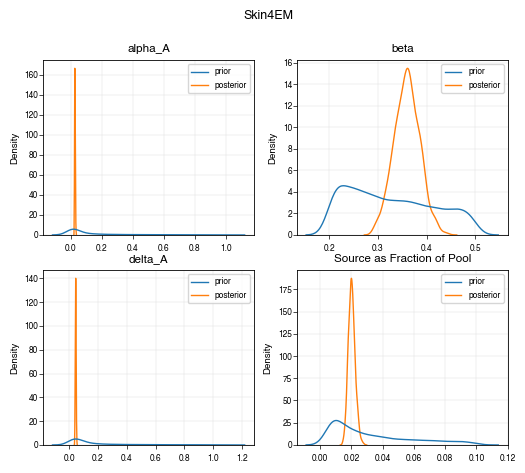

In [4]:

populationc = ['4EM']
organc = ['SK']
niceorganc=["Skin"]


fullloc = location+"/stan-cache-"+populationc[0]+precursor[m]+kimode[m]+organc[0]+"_"+str(1)+"/"
m=m+1

fh = []

sys.path.insert(1, fullloc)
import paras
reload(paras)

for f_name in os.listdir(fullloc):
    if f_name.endswith('.csv')&f_name.startswith('homog'):
#                 print(fullloc+f_name)
        fh.append(fullloc+f_name)
sam = cmdstanpy.from_csv(fh)

sm = cmdstanpy.CmdStanModel(stan_file="/home/elise/Dropbox/elisepaperclone/CD4TRM/stan_files/priors.stan")

data_dict = {
    "kcounts_y": paras.counts_t0_y,
    "alpha_A_data": paras.alpha_A,
    "beta_data" : paras.beta,
    "Source_data" : paras.Source,
    "a_y_data":paras.a_y,
    "a_t_data":paras.a_t,
    "b_y_data":paras.b_y,
    "b_t_data":paras.b_t,
    }

init_d = {

    "Source" : paras.Source,
    "alpha_A": paras.alpha_A,
    "beta" : paras.beta,
    "a_y":paras.a_y,
    "a_t":paras.a_t,
    "b_y":paras.b_y,
    "b_t":paras.b_t,

    }


cmdstanpy.write_stan_json("/home/elise/Dropbox/elisepaperclone/CD4TRM/stan_files/priors.json", data_dict)
sam_pL = sm.sample(
    data="/home/elise/Dropbox/elisepaperclone/CD4TRM/stan_files/priors.json", 
    chains=1, 
    output_dir="/home/elise/Dropbox/elisepaperclone/CD4TRM/stan_files/stan-cache/",
    show_progress=True,
    seed=74654,
    #fixed_param=True,
    iter_sampling=5000,
)


fig, ax = plt.subplots(2, 2, figsize=(6,5))

ax1=ax[0,0]
sns.kdeplot(data={'prior':sam_pL.stan_variable('alpha_A'),
                  'posterior':sam.stan_variable('alpha_A')}, 
            ax = ax1,common_norm=False)
ax1.set_title('alpha_A')

ax1=ax[1,0]
sns.kdeplot(data={'prior':sam_pL.stan_variable('delta_A'),
                  'posterior':sam.stan_variable('delta_A')}, ax = ax1,common_norm=False)
ax1.set_title('delta_A')

ax1=ax[0,1]
sns.kdeplot(data={'prior':sam_pL.stan_variable('beta'),'posterior':sam.stan_variable('beta')}, ax = ax1,common_norm=False)
ax1.set_title('beta')

ax1=ax[1,1]
sns.kdeplot(data={'prior':sam_pL.stan_variable('Source')/paras.counts_t0_y,'posterior':sam.stan_variable('Source')/paras.counts_t0_y}, ax = ax1,common_norm=False)
ax1.set_title('Source as Fraction of Pool')
fig.suptitle(niceorganc[0]+populationc[0],fontsize=9)

fig.savefig('/home/elise/Dropbox/elisepaperclone/CD4TRM/Figures/figS3_'+organc[0]+populationc[0]+'.pdf', dpi='figure', format='pdf',
        bbox_inches='tight', pad_inches=0.1)

fig.savefig('/home/elise/Dropbox/elisepaperclone/CD4TRM/Figures/figS3_'+organc[0]+populationc[0]+'.png', dpi='figure', format='png',
        bbox_inches='tight', pad_inches=0.1)



13:47:38 - cmdstanpy - INFO - CmdStan start processing


chain 1 |          | 00:00 Status

13:47:38 - cmdstanpy - INFO - CmdStan done processing.


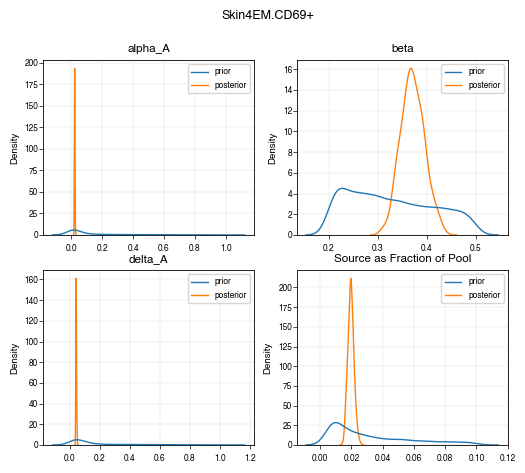

In [5]:

populationc = ['4EM.CD69+']
organc = ['SK']
niceorganc=["Skin"]


fullloc = location+"/stan-cache-"+populationc[0]+precursor[m]+kimode[m]+organc[0]+"_"+str(1)+"/"
m=m+1

fh = []

sys.path.insert(1, fullloc)
import paras
reload(paras)

for f_name in os.listdir(fullloc):
    if f_name.endswith('.csv')&f_name.startswith('homog'):
#                 print(fullloc+f_name)
        fh.append(fullloc+f_name)
sam = cmdstanpy.from_csv(fh)

sm = cmdstanpy.CmdStanModel(stan_file="/home/elise/Dropbox/elisepaperclone/CD4TRM/stan_files/priors.stan")

data_dict = {
    "kcounts_y": paras.counts_t0_y,
    "alpha_A_data": paras.alpha_A,
    "beta_data" : paras.beta,
    "Source_data" : paras.Source,
    "a_y_data":paras.a_y,
    "a_t_data":paras.a_t,
    "b_y_data":paras.b_y,
    "b_t_data":paras.b_t,
    }

init_d = {

    "Source" : paras.Source,
    "alpha_A": paras.alpha_A,
    "beta" : paras.beta,
    "a_y":paras.a_y,
    "a_t":paras.a_t,
    "b_y":paras.b_y,
    "b_t":paras.b_t,

    }


cmdstanpy.write_stan_json("/home/elise/Dropbox/elisepaperclone/CD4TRM/stan_files/priors.json", data_dict)
sam_pL = sm.sample(
    data="/home/elise/Dropbox/elisepaperclone/CD4TRM/stan_files/priors.json", 
    chains=1, 
    output_dir="/home/elise/Dropbox/elisepaperclone/CD4TRM/stan_files/stan-cache/",
    show_progress=True,
    seed=74654,
    #fixed_param=True,
    iter_sampling=5000,
)


fig, ax = plt.subplots(2, 2, figsize=(6,5))

ax1=ax[0,0]
sns.kdeplot(data={'prior':sam_pL.stan_variable('alpha_A'),
                  'posterior':sam.stan_variable('alpha_A')}, 
            ax = ax1,common_norm=False)
ax1.set_title('alpha_A')

ax1=ax[1,0]
sns.kdeplot(data={'prior':sam_pL.stan_variable('delta_A'),
                  'posterior':sam.stan_variable('delta_A')}, ax = ax1,common_norm=False)
ax1.set_title('delta_A')

ax1=ax[0,1]
sns.kdeplot(data={'prior':sam_pL.stan_variable('beta'),'posterior':sam.stan_variable('beta')}, ax = ax1,common_norm=False)
ax1.set_title('beta')

ax1=ax[1,1]
sns.kdeplot(data={'prior':sam_pL.stan_variable('Source')/paras.counts_t0_y,'posterior':sam.stan_variable('Source')/paras.counts_t0_y}, ax = ax1,common_norm=False)
ax1.set_title('Source as Fraction of Pool')
fig.suptitle(niceorganc[0]+populationc[0],fontsize=9)

fig.savefig('/home/elise/Dropbox/elisepaperclone/CD4TRM/Figures/figS3_'+organc[0]+populationc[0]+'.pdf', dpi='figure', format='pdf',
        bbox_inches='tight', pad_inches=0.1)

fig.savefig('/home/elise/Dropbox/elisepaperclone/CD4TRM/Figures/figS3_'+organc[0]+populationc[0]+'.png', dpi='figure', format='png',
        bbox_inches='tight', pad_inches=0.1)


13:47:41 - cmdstanpy - INFO - CmdStan start processing


chain 1 |          | 00:00 Status

13:47:41 - cmdstanpy - INFO - CmdStan done processing.


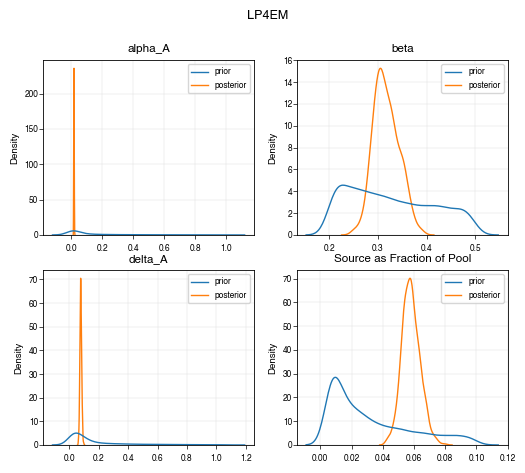

In [6]:
populationc = ['4EM']
organc = ['LP']
niceorganc=["LP"]


fullloc = location+"/stan-cache-"+populationc[0]+precursor[m]+kimode[m]+organc[0]+"_"+str(1)+"/"
m=m+1

fh = []

sys.path.insert(1, fullloc)
import paras
reload(paras)

for f_name in os.listdir(fullloc):
    if f_name.endswith('.csv')&f_name.startswith('homog'):
#                 print(fullloc+f_name)
        fh.append(fullloc+f_name)
sam = cmdstanpy.from_csv(fh)

sm = cmdstanpy.CmdStanModel(stan_file="/home/elise/Dropbox/elisepaperclone/CD4TRM/stan_files/priors.stan")

data_dict = {
    "kcounts_y": paras.counts_t0_y,
    "alpha_A_data": paras.alpha_A,
    "beta_data" : paras.beta,
    "Source_data" : paras.Source,
    "a_y_data":paras.a_y,
    "a_t_data":paras.a_t,
    "b_y_data":paras.b_y,
    "b_t_data":paras.b_t,
    }

init_d = {

    "Source" : paras.Source,
    "alpha_A": paras.alpha_A,
    "beta" : paras.beta,
    "a_y":paras.a_y,
    "a_t":paras.a_t,
    "b_y":paras.b_y,
    "b_t":paras.b_t,

    }


cmdstanpy.write_stan_json("/home/elise/Dropbox/elisepaperclone/CD4TRM/stan_files/priors.json", data_dict)
sam_pL = sm.sample(
    data="/home/elise/Dropbox/elisepaperclone/CD4TRM/stan_files/priors.json", 
    chains=1, 
    output_dir="/home/elise/Dropbox/elisepaperclone/CD4TRM/stan_files/stan-cache/",
    show_progress=True,
    seed=74654,
    #fixed_param=True,
    iter_sampling=5000,
)


fig, ax = plt.subplots(2, 2, figsize=(6,5))

ax1=ax[0,0]
sns.kdeplot(data={'prior':sam_pL.stan_variable('alpha_A'),
                  'posterior':sam.stan_variable('alpha_A')}, 
            ax = ax1,common_norm=False)
ax1.set_title('alpha_A')

ax1=ax[1,0]
sns.kdeplot(data={'prior':sam_pL.stan_variable('delta_A'),
                  'posterior':sam.stan_variable('delta_A')}, ax = ax1,common_norm=False)
ax1.set_title('delta_A')

ax1=ax[0,1]
sns.kdeplot(data={'prior':sam_pL.stan_variable('beta'),'posterior':sam.stan_variable('beta')}, ax = ax1,common_norm=False)
ax1.set_title('beta')

ax1=ax[1,1]
sns.kdeplot(data={'prior':sam_pL.stan_variable('Source')/paras.counts_t0_y,'posterior':sam.stan_variable('Source')/paras.counts_t0_y}, ax = ax1,common_norm=False)
ax1.set_title('Source as Fraction of Pool')
fig.suptitle(niceorganc[0]+populationc[0],fontsize=9)

fig.savefig('/home/elise/Dropbox/elisepaperclone/CD4TRM/Figures/figS3_'+organc[0]+populationc[0]+'.pdf', dpi='figure', format='pdf',
        bbox_inches='tight', pad_inches=0.1)

fig.savefig('/home/elise/Dropbox/elisepaperclone/CD4TRM/Figures/figS3_'+organc[0]+populationc[0]+'.png', dpi='figure', format='png',
        bbox_inches='tight', pad_inches=0.1)


13:47:44 - cmdstanpy - INFO - CmdStan start processing


chain 1 |          | 00:00 Status

13:47:44 - cmdstanpy - INFO - CmdStan done processing.


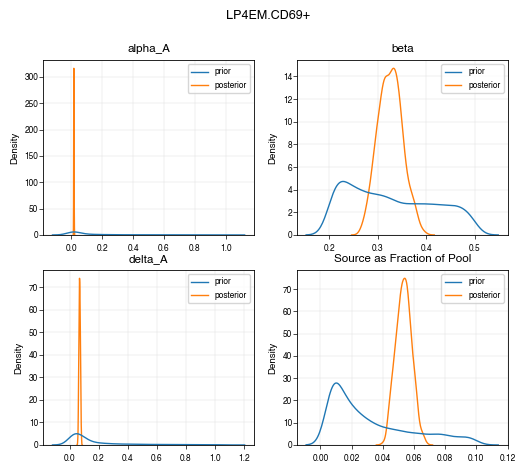

In [7]:
populationc = ['4EM.CD69+']
organc = ['LP']
niceorganc=["LP"]


fullloc = location+"/stan-cache-"+populationc[0]+precursor[m]+kimode[m]+organc[0]+"_"+str(1)+"/"
m=m+1

fh = []

sys.path.insert(1, fullloc)
import paras
reload(paras)

for f_name in os.listdir(fullloc):
    if f_name.endswith('.csv')&f_name.startswith('homog'):
#                 print(fullloc+f_name)
        fh.append(fullloc+f_name)
sam = cmdstanpy.from_csv(fh)

sm = cmdstanpy.CmdStanModel(stan_file="/home/elise/Dropbox/elisepaperclone/CD4TRM/stan_files/priors.stan")

data_dict = {
    "kcounts_y": paras.counts_t0_y,
    "alpha_A_data": paras.alpha_A,
    "beta_data" : paras.beta,
    "Source_data" : paras.Source,
    "a_y_data":paras.a_y,
    "a_t_data":paras.a_t,
    "b_y_data":paras.b_y,
    "b_t_data":paras.b_t,
    }

init_d = {

    "Source" : paras.Source,
    "alpha_A": paras.alpha_A,
    "beta" : paras.beta,
    "a_y":paras.a_y,
    "a_t":paras.a_t,
    "b_y":paras.b_y,
    "b_t":paras.b_t,

    }


cmdstanpy.write_stan_json("/home/elise/Dropbox/elisepaperclone/CD4TRM/stan_files/priors.json", data_dict)
sam_pL = sm.sample(
    data="/home/elise/Dropbox/elisepaperclone/CD4TRM/stan_files/priors.json", 
    chains=1, 
    output_dir="/home/elise/Dropbox/elisepaperclone/CD4TRM/stan_files/stan-cache/",
    show_progress=True,
    seed=74654,
    #fixed_param=True,
    iter_sampling=5000,
)


fig, ax = plt.subplots(2, 2, figsize=(6,5))

ax1=ax[0,0]
sns.kdeplot(data={'prior':sam_pL.stan_variable('alpha_A'),
                  'posterior':sam.stan_variable('alpha_A')}, 
            ax = ax1,common_norm=False)
ax1.set_title('alpha_A')

ax1=ax[1,0]
sns.kdeplot(data={'prior':sam_pL.stan_variable('delta_A'),
                  'posterior':sam.stan_variable('delta_A')}, ax = ax1,common_norm=False)
ax1.set_title('delta_A')

ax1=ax[0,1]
sns.kdeplot(data={'prior':sam_pL.stan_variable('beta'),'posterior':sam.stan_variable('beta')}, ax = ax1,common_norm=False)
ax1.set_title('beta')

ax1=ax[1,1]
sns.kdeplot(data={'prior':sam_pL.stan_variable('Source')/paras.counts_t0_y,'posterior':sam.stan_variable('Source')/paras.counts_t0_y}, ax = ax1,common_norm=False)
ax1.set_title('Source as Fraction of Pool')
fig.suptitle(niceorganc[0]+populationc[0],fontsize=9)

fig.savefig('/home/elise/Dropbox/elisepaperclone/CD4TRM/Figures/figS3_'+organc[0]+populationc[0]+'.pdf', dpi='figure', format='pdf',
        bbox_inches='tight', pad_inches=0.1)

fig.savefig('/home/elise/Dropbox/elisepaperclone/CD4TRM/Figures/figS3_'+organc[0]+populationc[0]+'.png', dpi='figure', format='png',
        bbox_inches='tight', pad_inches=0.1)
